# Data Wrangling — Synthetic Vietnamese Students’ Feedback

Nguồn: [Kaggle — toreleon/synthetic-vietnamese-students-feedback-corpus](https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus)

1. `student_feedback_data/synthetic_train.csv` (train)  
2. `student_feedback_data/synthetic_val.csv` (validation)  

Dữ liệu **văn bản**: missing → làm sạch câu; chuẩn hoá đơn vị → điểm sentiment; normalize → độ dài câu; binning → ngắn/trung/dài; dummy → `topic`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

In [ ]:
! pip install kagglehub

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("toreleon/synthetic-vietnamese-students-feedback-corpus")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\CHAU TINH TIEN\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1


## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? câu rỗng / chỉ khoảng trắng?

| Cột | Kiểu | Ý nghĩa |
|---|---|---|
| `sentence` | object | Câu phản hồi (VN hoặc EN). Không trùng trong từng file. |
| `sentiment` | object | Nhãn cảm xúc: `negative` / `neutral` / `positive` (gần cân bằng). |
| `topic` | object | Chủ đề: `lecturer`, `curriculum`, `facility`, `others`. |

**Ghi chú:** Không có `NaN` sẵn. Một số câu là tiếng Anh (không dấu). Cần tạo biến số (độ dài câu) để normalize / binning.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

path_train = os.path.join(path, "synthetic_train.csv")
path_val = os.path.join(path, "synthetic_val.csv")

df_train = pd.read_csv(path_train)  # mẫu: đọc train
# TODO: đọc path_val vào df_val (giống dòng trên)
df_val = pd.read_csv(path_val)

print("Train:", df_train.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_val
print("Val:", df_val.shape)

print(df_train.dtypes)  # mẫu: xem kiểu cột
df_train.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_val
df_val.head()

Train: (8144, 3)
Val: (2036, 3)
sentence     str
sentiment    str
topic        str
dtype: object


,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,facility
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,curriculum
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,others


---
# Bộ 1 — Train

## 1. Xử lý giá trị thiếu (Missing Values)

Câu rỗng / chỉ khoảng trắng → `NaN`. `sentiment` / `topic` (phân loại) → **mode**. `sentence` là nội dung chính → **drop** dòng thiếu rồi `reset_index`.

In [4]:
df = df_train.copy()  # mẫu: làm việc trên bản sao

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu: cắt khoảng trắng câu
# TODO: strip tương tự cho sentiment và topic
df["sentiment"] = df["sentiment"].astype(str).str.strip()

df["topic"]= df["topic"].astype(str).str.strip()
# TODO: replace {"nan": np.nan, "": np.nan, "None": np.nan} trên 3 cột (có thể dùng vòng for)
cols = ["sentence","sentiment","topic"]
for col in cols:
    df[col]=df[col].replace({"nan": np.nan, "": np.nan, "None": np.nan})

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode(dropna=True)[0])  # mẫu: cột chữ → mode
# TODO: fillna mode cho cột topic (copy mẫu, đổi tên cột)
df["topic"]= df["topic"].fillna(df["topic"].mode(dropna=True) [0])

# TODO: dropna subset=["sentence"] rồi reset_index (câu là nội dung chính — không điền mode)
df= df.dropna(subset=["sentence"]).reset_index(drop=True)

# TODO: in lại isnull().sum() và len(df)
print(df.isnull().sum())
print("Tổng số dòng sau xử lý:", len(df))

sentence     0
sentiment    0
topic        0
dtype: int64
sentence     0
sentiment    0
topic        0
dtype: int64
Tổng số dòng sau xử lý: 8144


## 2. Sửa định dạng dữ liệu (Correct Data Format)

Ép `sentiment`, `topic` về kiểu `category`. Thêm độ dài câu (`n_chars`, `n_words`) dạng số.

In [5]:
print(df.dtypes)  # mẫu: kiểu trước khi ép

df["sentiment"] = df["sentiment"].astype("category")  # mẫu: chữ → category
# TODO: ép topic về category (giống dòng trên)
df["topic"]=df["topic"].astype("category")

df["n_chars"] = df["sentence"].str.len().astype(int)  # mẫu: số ký tự
# TODO: n_words = sentence.str.split().str.len() rồi astype(int)
df["n_words"] = df["sentence"].str.split().str.len().astype(int)

df[["sentence", "n_chars"]].head()  # mẫu
# TODO: head thêm cột n_words; in lại dtypes
print(df["n_words"].head())
print(df.dtypes)


sentence     str
sentiment    str
topic        str
dtype: object
0    19
1     8
2    14
3    15
4    34
Name: n_words, dtype: int64
sentence          str
sentiment    category
topic        category
n_chars         int64
n_words         int64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Đưa nhãn cảm xúc về **cùng thang số**: `negative → -1`, `neutral → 0`, `positive → 1`.

In [6]:
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu: từ điển nhãn → số

# TODO: cột sentiment_score = df["sentiment"].map(sentiment_map).astype(int)
df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)


df[["sentiment"]].drop_duplicates()  # mẫu: xem các nhãn
# TODO: head / drop_duplicates hai cột sentiment và sentiment_score
print(df[["sentiment", "sentiment_score"]].head())
print(df[["sentiment","sentiment_score"]].drop_duplicates())



  sentiment  sentiment_score
0  negative               -1
1   neutral                0
2   neutral                0
3  positive                1
4   neutral                0
  sentiment  sentiment_score
0  negative               -1
1   neutral                0
3  positive                1


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`n_chars` lớn hơn `n_words` → `x / x.max()` về 0–1.

In [7]:
print(df.columns.tolist())

['sentence', 'sentiment', 'topic', 'n_chars', 'n_words', 'sentiment_score']


In [8]:
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu: chia max → 0–1
# TODO: n_words_normalized = n_words / n_words.max()
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()

df[["n_chars", "n_words","n_words_normalized", "n_chars_normalized"]].head()  # mẫu
# TODO: head thêm n_words và n_words_normalized

,n_chars,n_words,n_words_normalized,n_chars_normalized
0,86,19,0.441860,0.452632
1,63,8,0.186047,0.331579
2,68,14,0.325581,0.357895
3,75,15,0.348837,0.394737
4,142,34,0.790698,0.747368


## 5. Phân nhóm (Binning)

Chia độ dài câu (số từ) thành Short / Medium / Long bằng `pd.cut()`.

In [9]:
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)  # mẫu: 3 khoảng đều

df["length_binned"] = pd.cut(
    df["n_words"], bins=bins, labels=["Short", "Medium", "Long"], include_lowest=True
)  # mẫu: gán nhãn

print(df["length_binned"].value_counts())  # mẫu: đếm mỗi nhóm

# TODO: plt.hist(df["n_words"], bins=3) rồi xlabel / ylabel / title / show

df[["n_words", "length_binned"]].head()

length_binned
Short     5070
Medium    2978
Long        96
Name: count, dtype: int64


,n_words,length_binned
0,19,Medium
1,8,Short
2,14,Short
3,15,Short
4,34,Long


## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`topic` (chữ) → mỗi chủ đề một cột 0/1. Giữ `sentiment` làm nhãn dự đoán.

In [15]:
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_topic], axis=1)
df = pd.concat([df,dummy_topic],axis=1)

# TODO: xoá cột gốc topic — df.drop(columns=["topic"])  (giữ sentiment)
df =  df.drop(columns=["topic"])

df.head()  # mẫu

,sentence,sentiment,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Chất lượng vật chất kém.,negative,0,1,0,0
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,0,1,0,0
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,0,1,0,0
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,1,0,0,0
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,0,0,0,1


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `n_chars`, `n_words` là số
* có cột mới: `sentiment_score`, `*_normalized`, `length_binned`, `topic_*`

`index=False` để file không thêm cột index 0,1,2,…


In [16]:
df.to_csv("student_feedback_train_clean.csv", index=False)  # mẫu: lưu train
print(df.shape)

# TODO: (tuỳ chọn) gán df_train_clean = df
df_train_clean = df

(2036, 6)


---
---
# Bộ 2 — Validation

Làm **giống bộ train**, đổi `df_train` → `df_val`. Copy mẫu ở trên, sửa tên biến / title. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


Thống kê nhóm độ dài (Val):
n_chars_bin
(58.75, 110.5]     1311
(7.0, 58.75]        616
(110.5, 162.25]     101
(162.25, 214.0]       7
Name: count, dtype: int64


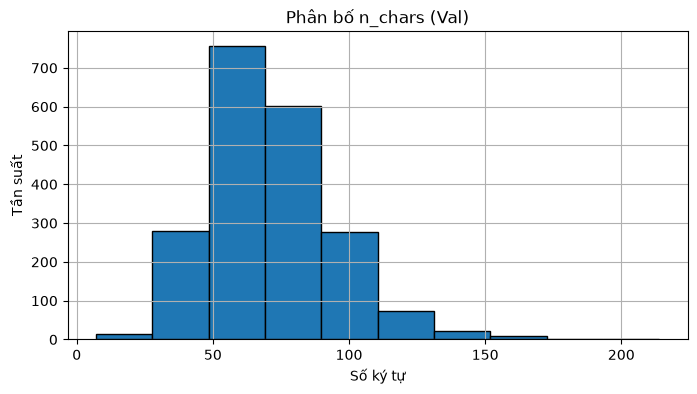

Kích thước dữ liệu Val sau khi xử lý: (2036, 12)


,sentence,sentiment,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,n_chars_bin,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Chất lượng vật chất kém.,negative,24,5,-1,0.112150,0.104167,"(7.0, 58.75]",0,1,0,0
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,68,15,-1,0.317757,0.312500,"(58.75, 110.5]",0,1,0,0
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,120,25,-1,0.560748,0.520833,"(110.5, 162.25]",0,1,0,0
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,64,14,0,0.299065,0.291667,"(58.75, 110.5]",1,0,0,0
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,57,12,0,0.266355,0.250000,"(7.0, 58.75]",0,0,0,1


In [17]:
df = df_val.copy()  # mẫu: bắt đầu từ validation

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu bước 1
# TODO: strip + replace nan/""/"None" cho sentiment, topic; fillna mode; dropna sentence
cols_to_clean = ["sentiment", "topic"]
for col in cols_to_clean:
    df[col]=df[col].astype(str).str.strip()
    df[col] = df[col].replace(["", "nan", "None", "NaN"], np.nan)
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
df["sentence"] = df["sentence"].replace(["", "nan", "None", "NaN"], np.nan)
df = df.dropna(subset=["sentence"])


df["sentiment"] = df["sentiment"].astype("category")  # mẫu bước 2
# TODO: ép topic; tạo n_chars (đã có mẫu train) và n_words
df["topic"] = df["topic"].astype("category")
df["n_chars"] = df["sentence"].str.len()
df["n_words"] = df["sentence"].str.split().str.len()

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu bước 3
# TODO: sentiment_score = map rồi astype(int)
df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)

df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu bước 4
# TODO: n_words_normalized
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()

# TODO: bước 5 — linspace + pd.cut + value_counts + hist (title Val)
bins = np.linspace(df["n_chars"].min(), df["n_chars"].max(), 5)
df["n_chars_bin"] = pd.cut(df["n_chars"], bins=bins)
print("Thống kê nhóm độ dài (Val):")
print(df["n_chars_bin"].value_counts())

plt.figure(figsize=(8, 4))
df["n_chars"].hist(bins=10, edgecolor="black")
plt.title("Phân bố n_chars (Val)")
plt.xlabel("Số ký tự")
plt.ylabel("Tần suất")
plt.show()

dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu bước 6
# TODO: concat + drop topic
df = pd.concat([df, dummy_topic], axis=1)
df = df.drop(columns=["topic"])

# TODO: to_csv student_feedback_val_clean.csv; print shape; df.head()
df.to_csv("student_feedback_val_clean.csv", index=False)
print("Kích thước dữ liệu Val sau khi xử lý:", df.shape)
df.head()